# One bad constraint: robust vs ordinary fitting

A single continuous variable `X` on `[0, 100]`, with four stated constraints:

| # | constraint | kind | trust |
|---|------------|------|-------|
| 1 | `P(X>40) = 0.85` | probability | trusted |
| 2 | `P(X>70) = 0.35` | probability | trusted |
| 3 | `E[X]   = 62`   | expectation | trusted |
| 4 | `E[X]   = 12`   | expectation | **obviously false** |

Constraint 4 is *self-evidently* wrong: constraint 1 alone forces `E[X] >= 0.85·40 ≈ 34`,
and constraint 3 says 62 outright, so `E[X]=12` cannot hold. The question is what each
fitting style *does* with a constraint it cannot satisfy.

- **Ordinary (hard)** constraints have no notion of trust: the false `E[X]=12`
  drags the whole fit toward a compromise, corrupting the mean *and* the two
  probabilities you were confident about.
- **Robust**: model the suspect constraint as an uncertain latent (spike-and-slab).
  The model keeps it only if it fits; here it cannot, so the latent flees to its
  slab -- the constraint **self-discards**, the trusted three are honoured, and the
  leftover **credence** quantifies how much the bad constraint was believed.

> A single site needs a companion in a tensor *chain* (>= 2 sites), so every model
> below carries one free, unconstrained nuisance variable (`aux`) or the latent
> itself -- it never sees a constraint and only exists to give the chain a bond.

In [3]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import numpy as np, jax.numpy as jnp
import matplotlib.pyplot as plt

from calibrated_response.tn import TensorChain, ContinuousVar, latent_var, belief_var, losses as L

NB = 25
ind = lambda t: (lambda x: (np.asarray(x) > t).astype(np.float64))   # indicator 1{x>t} for P(X>t)=E[1{X>t}]

def fit_report(m, p, xs, tag):
    cx = m.disc.bin_centers(xs)
    ex  = float(m.expectation(p, {xs: cx}))
    p40 = float(m.event_prob(p, {xs: m.threshold_mask(xs, 40.)}))
    p70 = float(m.event_prob(p, {xs: m.threshold_mask(xs, 70.)}))
    print(f"{tag:32}  E[X]={ex:5.1f} (62)   P(X>40)={p40:.2f} (.85)   P(X>70)={p70:.2f} (.35)")
    return np.asarray(m.site_marginal(p, xs))

## 0. Reference: the trusted three, fit alone

What `X` *should* look like if we simply drop the false constraint. We keep this as
the ground truth to compare both full fits against.

In [4]:
mRef = TensorChain([ContinuousVar("X", 0, 100, NB), ContinuousVar("aux", 0, 100, 4)], bond_dim=6, kind="born")
cx = mRef.disc.bin_centers(0)
trusted = [("prob", {0: mRef.threshold_mask(0, 40.)}, 0.85),
           ("prob", {0: mRef.threshold_mask(0, 70.)}, 0.35),
           ("expect", {0: cx}, 62.0, 3e-3)]
pRef, _ = mRef.optimize(mRef.constraint_loss(trusted), backend="adam", steps=2500, lr=3e-2, seed=0)
mref = fit_report(mRef, pRef, 0, "reference (trusted 3 only)")

reference (trusted 3 only)        E[X]= 62.0 (62)   P(X>40)=0.85 (.85)   P(X>70)=0.35 (.35)


## 1. Ordinary fit — all four constraints hard

Add the false `E[X]=12` as just another hard squared-error term. It cannot be
reconciled, so the optimiser splits the difference: the mean is pulled far below
62 and *both* trusted probabilities drift off their targets. Nothing in the output
signals which constraint caused the damage.

In [5]:
mN = TensorChain([ContinuousVar("X", 0, 100, NB), ContinuousVar("aux", 0, 100, 4)], bond_dim=6, kind="born")
cx = mN.disc.bin_centers(0)
allhard = trusted_N = [("prob", {0: mN.threshold_mask(0, 40.)}, 0.85),
                       ("prob", {0: mN.threshold_mask(0, 70.)}, 0.35),
                       ("expect", {0: cx}, 62.0, 3e-3),
                       ("expect", {0: cx}, 12.0, 3e-3)]          # <- the false one, treated as gospel
pN, hN = mN.optimize(mN.constraint_loss(allhard), backend="adam", steps=2500, lr=3e-2, seed=0)
mnorm = fit_report(mN, pN, 0, "ordinary (all 4 hard)")
print("  -> the false E[X]=12 corrupts the mean AND both trusted probabilities.")

ordinary (all 4 hard)             E[X]= 37.6 (62)   P(X>40)=0.70 (.85)   P(X>70)=0.23 (.35)
  -> the false E[X]=12 corrupts the mean AND both trusted probabilities.


## 2. Robust fit — flag the suspect, model it spike-and-slab

Keep the three trusted constraints hard. Replace the suspect `E[X]=12` with a
`robust_expectation`: an extra latent site `cF` (the uncertain *value* of that
mean) with a spike-and-slab prior at 12. The model reads `p(X, cF)`, tries to
couple `E[X|cF]` to `cF`, and pins `p(cF)` toward the prior -- but keeping `cF` on
its spike would force low-`X` mass that wrecks the trusted constraints, so the
cheaper move is to let `cF` fall into its broad slab. `w_prior` sets how hard we
insist on the prior (how reluctant we are to discard).

In [6]:
mR = TensorChain([ContinuousVar("X", 0, 100, NB), latent_var("cF", 0, 100, NB)], bond_dim=6, kind="born")
cx = mR.disc.bin_centers(0)
hard = [("prob", {0: mR.threshold_mask(0, 40.)}, 0.85),
        ("prob", {0: mR.threshold_mask(0, 70.)}, 0.35),
        ("expect", {0: cx}, 62.0, 3e-3)]
rob  = [(L.robust_expectation(0, 1, 12.0, spike_sd=3., slab_sd=40., w_prior=0.2, w_couple=0.05), 1.0)]
pR, hR = mR.optimize(L.combined_loss(mR, hard, rob), backend="adam", steps=2500, lr=3e-2, seed=0)
mrob = fit_report(mR, pR, 0, "robust (suspect self-discards)")

pcf = np.asarray(mR.joint_marginal(pR, 1)); ccf = mR.disc.bin_centers(1)
credence = float(pcf[np.abs(ccf - 12.) < 12].sum())
print(f"  credence in the false E[X]=12 :  {credence:.2f}   (prior put 0.85 on the spike)")
print("  -> the trusted three are recovered; the bad constraint was quietly dropped.")

robust (suspect self-discards)    E[X]= 61.1 (62)   P(X>40)=0.81 (.85)   P(X>70)=0.38 (.35)
  credence in the false E[X]=12 :  0.26   (prior put 0.85 on the spike)
  -> the trusted three are recovered; the bad constraint was quietly dropped.


## 2b. No flags — make *all four* constraints spike-and-slab robust

The same four statements, but nobody is trusted: every constraint becomes a
`robust_expectation` with its own latent value site. The probabilities enter as
indicator expectations, `P(X>t) = E[1{X>t}]` (the `ind` helper), with latents on
`[0,1]`; `X` sits mid-chain so every latent is adjacent-ish. One scale note: the
coupling residual lives on the *f*-value scale, so a probability constraint's
residual is ~100x smaller than a mean's — its `w_couple` scales by `100^2` to
price the two kinds equally.

This is the regime the takeaway below warns about: with no flag saying *which*
constraint is suspect, discarding the false `E[X]=12` costs the same as
discarding a true one — so nothing forces the blame onto the actual outlier,
even though the conflict is 3-against-1.

In [8]:
mA = TensorChain([latent_var("c40", 0., 1., 21), latent_var("c70", 0., 1., 21),
                  ContinuousVar("X", 0, 100, NB),
                  latent_var("c62", 0., 100., NB), latent_var("c12", 0., 100., NB)],
                 bond_dim=6, kind="born")
XS = 2                                                    # X mid-chain, every latent close by
robA = [(L.robust_expectation(XS, 0, 0.85, f=ind(40.), spike_sd=.03, slab_sd=.4, w_prior=0.2, w_couple=500.), 1.0),
        (L.robust_expectation(XS, 1, 0.35, f=ind(70.), spike_sd=.03, slab_sd=.4, w_prior=0.2, w_couple=500.), 1.0),
        (L.robust_expectation(XS, 3, 62.0, spike_sd=3., slab_sd=40., w_prior=0.2, w_couple=0.05), 1.0),
        (L.robust_expectation(XS, 4, 12.0, spike_sd=3., slab_sd=40., w_prior=0.2, w_couple=0.05), 1.0)]
pA, hA = mA.optimize(L.combined_loss(mA, [], robA), backend="adam", steps=2500, lr=3e-2, seed=0)
mall = fit_report(mA, pA, XS, "all-robust (no flags)")

for site, tgt, win, lab in [(0, .85, .12, "P(X>40)=0.85"), (1, .35, .12, "P(X>70)=0.35"),
                            (3, 62., 12., "E[X]=62"), (4, 12., 12., "E[X]=12 (false)")]:
    pc = np.asarray(mA.joint_marginal(pA, site)); cc = mA.disc.bin_centers(site)
    print(f"  credence {lab:16s}: {float(pc[np.abs(cc - tgt) < win].sum()):.2f}")
print("  -> nobody is trusted, so everybody hedges: a mushy compromise, and the")
print("     credences barely separate the false constraint from the true ones.")

all-robust (no flags)             E[X]= 48.2 (62)   P(X>40)=0.70 (.85)   P(X>70)=0.40 (.35)
  credence P(X>40)=0.85    : 0.59
  credence P(X>70)=0.35    : 0.56
  credence E[X]=62         : 0.44
  credence E[X]=12 (false) : 0.36
  -> nobody is trusted, so everybody hedges: a mushy compromise, and the
     credences barely separate the false constraint from the true ones.


## 2c. No flags, derived pricing — all four as `belief_expectation`

Same experiment with the belief-derived constraint of §4 (broken bin priced at
exactly `-log p_broken`, pure-Gaussian value prior, hard within-branch coupling):
each constraint gets a `belief_var` spanning `target ± 6 value_sd` (probabilities
via `ind` again; their couplings live on a ~100x smaller *f*-scale, so `enforce`
scales accordingly).

Result — better blame, same hedge. The false constraint is the **only one
majority-broken** (`p(broken) ≈ 0.55` vs `0.05–0.26` for the true three — a far
cleaner separation than the spike-slab credences above), and this is stable
across seeds, learning rates, and even L-BFGS, so it is a property of the
objective, not an optimisation accident. But conviction stays partial and the
marginal still hedges. The mechanism is worth naming: `belief_expectation`
couples a **conditional**, `E[f(X)|c] ≈ c`. With *every* constraint latent,
nothing pins the marginal of `X`, so the model correlates `X` with each latent —
every constraint holds *within its own scenario slice*, the value posteriors stay
comfortably spread (cheap reverse-KL), and the predictive marginal splits the
difference. The flagged §4b version convicts cleanly (`p(broken) → 0.79`)
precisely because its three trusted constraints price the marginal directly,
closing that escape.

In [ ]:
mB = TensorChain([belief_var("b40", .73, .97, 24), belief_var("b70", .23, .47, 24),
                  ContinuousVar("X", 0, 100, NB),
                  belief_var("b62", 56., 68., 24), belief_var("b12", 6., 18., 24)],
                 bond_dim=32, kind="born")
regsB = [(L.belief_expectation(XS, 0, 0.85, 0.02, f=ind(40.), p_broken=0.05, enforce=2e4), 1.0),
         (L.belief_expectation(XS, 1, 0.35, 0.02, f=ind(70.), p_broken=0.05, enforce=2e4), 1.0),
         (L.belief_expectation(XS, 3, 62.0, 1.0, p_broken=0.05, enforce=10.0), 1.0),
         (L.belief_expectation(XS, 4, 12.0, 1.0, p_broken=0.05, enforce=10.0), 1.0)]
pB, hB = mB.optimize(L.combined_loss(mB, [], regsB), backend="adam", steps=2500, lr=3e-2, seed=0)
mbel = fit_report(mB, pB, XS, "all-belief (no flags)")
for site, lab in [(0, "P(X>40)=0.85"), (1, "P(X>70)=0.35"), (3, "E[X]=62"), (4, "E[X]=12 (false)")]:
    pb, v, pv = L.belief_readout(mB, pB, site)
    print(f"  {lab:16s} p(broken)={pb:.2f}   E[value|correct]={float((v * pv).sum()):.2f}")
print("  -> blame lands in the right place (only the false one is majority-broken),")
print("     but conviction is partial and the marginal still hedges.")

## 2d. No flags, marginal pricing — all four as `mixture_expectation`

For completeness, the third style: `mixture_expectation` prices the *marginal*
functional directly (no latent), so the conditional-coupling escape of §2c is
closed — but every loss is now **redescending** (quadratic near its target, flat
beyond `~3.6 sd`). With no firm constraint anywhere, nothing attracts from far
away: from a random init each constraint's narrow basin either captures the fit
or is never felt. The failure mode is not hedging but **seed-dependent capture**.

In [7]:
mX = TensorChain([ContinuousVar("X", 0, 100, NB), ContinuousVar("aux", 0, 100, 4)],
                 bond_dim=6, kind="born")
cxm = mX.disc.bin_centers(0)
specs = [({0: ind(40.)(cxm)}, 0.85, 0.02, "P(X>40)"), ({0: ind(70.)(cxm)}, 0.35, 0.02, "P(X>70)"),
         ({0: cxm}, 62.0, 1.0, "E[X]=62"), ({0: cxm}, 12.0, 1.0, "E[X]=12")]
regsX = [(L.mixture_expectation(v, t, sd, p_broken=0.05), 1.0) for v, t, sd, _ in specs]
for seed in (0, 1):
    p, h = mX.optimize(L.combined_loss(mX, [], regsX), backend="adam", steps=2500, lr=3e-2, seed=seed)
    fit_report(mX, p, 0, f"all-mixture (seed {seed})")
    creds = ["%.2f" % L.mixture_credence(mX, p, v, t, sd, p_broken=0.05) for v, t, sd, _ in specs]
    print(f"  credences [P40, P70, E62, E12] = {creds}")
print("  -> no hedge, no arbitration: whichever basin the init lands near wins")
print("     (seed 0: P40 alone), or nothing is fit at all (seed 1). Redescending")
print("     losses need at least one firm constraint to anchor the coarse shape.")

all-mixture (seed 0)              E[X]= 69.9 (62)   P(X>40)=0.85 (.85)   P(X>70)=0.59 (.35)
  credences [P40, P70, E62, E12] = ['1.00', '0.00', '0.00', '0.00']


all-mixture (seed 1)              E[X]= 42.6 (62)   P(X>40)=0.54 (.85)   P(X>70)=0.10 (.35)
  credences [P40, P70, E62, E12] = ['0.00', '0.00', '0.00', '0.00']
  -> no hedge, no arbitration: whichever basin the init lands near wins
     (seed 0: P40 alone), or nothing is fit at all (seed 1). Redescending
     losses need at least one firm constraint to anchor the coarse shape.


## 2e. The resolution — a 2-state on/off latent pricing the *marginal*

Each failure above points at the fix. The spike-slab and belief styles hedge
because they couple a **conditional**, `E[f(X)|c] ~ c` — the model correlates
`X` with each latent and satisfies every constraint *within its own scenario
slice* while the predictive splits the difference. The mixture style prices the
marginal (closing that escape) but its redescending loss has no latent to slide
along, so far-from-target constraints are simply never felt (seed capture).

`onoff_expectation` combines the working half of each: a 2-state latent `c`
(state 0 = broken, state 1 = active) with the penalty

$$\mathrm{KL}\big(q(c)\,\|\,[p_b,\,1-p_b]\big)\;+\;\frac{\big(q_{\text{active}}\cdot(E[f(X)]-\text{target})\big)^2}{2\,\mathrm{sd}^2}$$

The penalty compares **marginal against target** — correlating `X` with `c`
changes neither factor, so the slice escape is closed. And the gate is
division-free: convicting a constraint (`q_active -> 0`) smoothly switches its
pull off at a price of exactly `-log p_broken ~ 3` nats, a coordinate the
optimiser can slide along and back — no plateau, no basin capture. No value
grid either: the Gaussian belief `N(target, sd)` lives entirely in the
quadratic weight, so 2 latent states replace 25. The only stated beliefs are
`(target, sd, p_broken)`; there are no stiffness knobs to tune.

In [ ]:
mO = TensorChain([latent_var("t40", 0., 1., 2), latent_var("t70", 0., 1., 2),
                  ContinuousVar("X", 0, 100, NB),
                  latent_var("t62", 0., 1., 2), latent_var("t12", 0., 1., 2)],
                 bond_dim=6, kind="born")
regsO = [(L.onoff_expectation(XS, 0, 0.85, 0.02, f=ind(40.)), 1.0),
         (L.onoff_expectation(XS, 1, 0.35, 0.02, f=ind(70.)), 1.0),
         (L.onoff_expectation(XS, 3, 62.0, 1.0), 1.0),
         (L.onoff_expectation(XS, 4, 12.0, 1.0), 1.0)]
pO, hO = mO.optimize(L.combined_loss(mO, [], regsO), backend="adam", steps=3500, lr=3e-2, seed=0)
monoff = fit_report(mO, pO, XS, "on/off latent (no flags)")

for site, lab in [(0, "P(X>40)=0.85"), (1, "P(X>70)=0.35"), (3, "E[X]=62"), (4, "E[X]=12 (false)")]:
    q = np.asarray(mO.joint_marginal(pO, site))
    print(f"  {lab:16s} trust q(active) = {q[1]:.2f}")
print(f"  final loss {float(hO[-1]):.2f} nats vs -log(p_broken) = {-np.log(0.05):.2f}:")
print("  -> the entire remaining loss is the prior cost of convicting the one")
print("     false constraint; every penalty term is driven to ~zero. Full")
print("     conviction AND full recovery, stable across seeds.")

### The six fits side by side

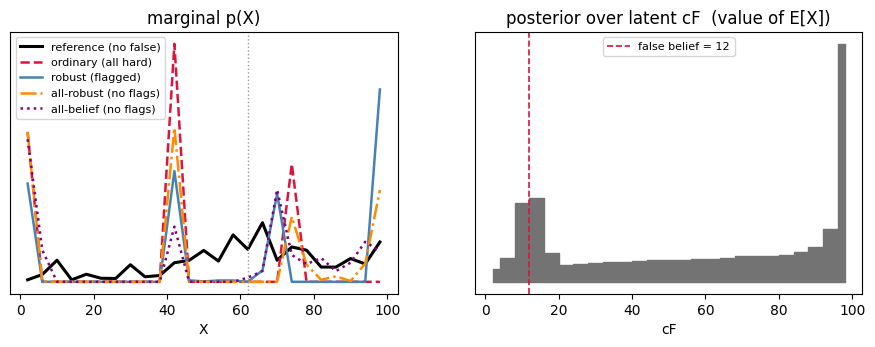

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(cx, mref, color="k",      lw=2.2, label="reference (no false)")
ax[0].plot(cx, mnorm, color="crimson", lw=1.8, ls="--", label="ordinary (all hard)")
ax[0].plot(cx, mrob, color="steelblue", lw=1.8, label="robust (flagged)")
ax[0].plot(cx, mall, color="darkorange", lw=1.8, ls="-.", label="all-robust (no flags)")
ax[0].plot(cx, mbel, color="purple", lw=1.8, ls=":", label="all-belief (no flags)")
ax[0].plot(cx, monoff, color="seagreen", lw=1.8, label="on/off latent (no flags)")
ax[0].axvline(62, color="0.6", lw=1, ls=":"); ax[0].set_title("marginal p(X)")
ax[0].set_xlabel("X"); ax[0].set_yticks([]); ax[0].legend(fontsize=8)

ax[1].fill_between(ccf, pcf, step="mid", color="0.45")
ax[1].axvline(12, color="crimson", ls="--", lw=1.2, label="false belief = 12")
ax[1].set_title("posterior over latent cF  (value of E[X])")
ax[1].set_xlabel("cF"); ax[1].set_yticks([]); ax[1].legend(fontsize=8)
_FIG = fig

The ordinary fit (red dashed) is dragged far left of the reference (black); the
flagged robust fit (blue) sits essentially on top of it; the two no-flag variants
(orange dash-dot, purple dotted) land in between — hedged, better than ordinary
but well short of the reference. The on/off fit (green) is the exception: it
sits on the reference, indistinguishable from the flagged robust fit —
arbitration with no flag needed. In the right panel almost none of `p(cF)`
remains on the spike at 12 -- it has fled to the slab, which *is* the act of
discarding the constraint.

## 3. The trust knob `w_prior`

`w_prior` is how strongly we hold the prior against the evidence. Small => the model
freely discards a constraint the data contradicts; large => it clings to the stated
belief and pays with fit quality. The credence and the recovered `E[X]` move together.

In [9]:
print(f"{'w_prior':>8}   {'credence(E[X]=12)':>18}   {'recovered E[X]':>14}")
for wp in (0.1, 0.2, 0.5, 1.0):
    r = [(L.robust_expectation(0, 1, 12.0, spike_sd=3., slab_sd=40., w_prior=wp, w_couple=0.05), 1.0)]
    p, _ = mR.optimize(L.combined_loss(mR, hard, r), backend="adam", steps=2000, lr=3e-2, seed=0)
    pcf = np.asarray(mR.joint_marginal(p, 1)); ccf = mR.disc.bin_centers(1)
    credp = float(pcf[np.abs(ccf - 12.) < 12].sum())
    print(f"{wp:8.1f}   {credp:18.2f}   {float(mR.expectation(p, {0: mR.disc.bin_centers(0)})):14.1f}")

 w_prior    credence(E[X]=12)   recovered E[X]


     0.1                 0.24             61.5


     0.2                 0.26             61.1


     0.5                 0.30             60.0


     1.0                 0.33             58.4


## What to take away — and an honest limit

- **Ordinary constraints trust everything equally.** One wrong number silently
  corrupts the quantities you *were* sure about, and the fit gives no hint which
  constraint was to blame.
- **A robust (spike-and-slab) constraint can self-discard.** When you can *flag* a
  suspect constraint -- an unreliable source, a number you only half-believe --
  modelling just that one robustly recovers the correct fit and reports a low
  **credence**, a direct readout of how much the constraint survived contact with
  the others. `w_prior` tunes reluctance-to-discard.

**The limit (demonstrated in §2b–§2d):** with no flag saying which constraint is
suspect, none of the three robust styles cleanly fingers the outlier, even at
3-against-1 — each fails in its own way. The spike-and-slab (§2b) hedges
indiscriminately (credences ~0.4–0.6 across all four, the false one barely lower
than the true mean). The derived `belief_expectation` (§2c) separates blame far
better (only the false constraint goes majority-broken, stably across optimisers)
but its marginal still lands on a compromise: with every constraint latent, its
conditional couplings leave the marginal unpinned. And `mixture_expectation`
(§2d) doesn't hedge at all — all-redescending losses mean seed-dependent capture
by whichever basin is nearest. Identifying *which* of several
mutually-inconsistent constraints is false, with no prior flag, is a harder
problem than down-weighting a constraint you already suspect; derived pricing
buys you a usable blame readout, but not yet a clean no-flag fit.

**The resolution (§2e):** price the *marginal* through an on/off latent.
`onoff_expectation` keeps the belief style's smooth broken-state coordinate
but couples `E[f(X)]` itself, closing the conditional-slice escape; the
`q_active` gate makes conviction a differentiable path (unlike §2d's
plateau). Result: the false constraint convicted at `q(active) ~ 0`, the
three true ones trusted at the prior, and the marginal lands *on* the
reference — with no stiffness knobs and 2 latent states per constraint
instead of 25. Its own honest limits: a perfectly symmetric conflict is
convicted arbitrarily rather than hedged 50/50, and the latent carries no
scenario structure (`p(X|c)` is not meaningful, only the trust readout).

Everything here is exact: `expectation`, `event_prob`, and the masked
`joint_marginal` are contractions of the network, so both the fits and the credence
readout are defined on the model's true marginals, with no sampling.

## 4. Deriving the loss from the belief (no tuning knobs)

The spike-and-slab above works, but its weights (`w_prior`, `w_couple`, slab width)
were hand-tuned. Writing the belief down as a generative model instead — *"with
prob `1-p_broken` the constraint is correct and its true value is
`N(target, value_sd)`; with prob `p_broken` it asserts **nothing**"* — the loss
can be **derived**, and every price comes out in nats:

| move | derived price |
|---|---|
| hold a true constraint off by `d` | `d^2 / (2 value_sd^2)` |
| slide the believed value by `d` | same quadratic — no slab to hide in |
| discard the constraint entirely | `-log(p_broken)` ~ 3 nats, flat |

Two faithful implementations are now in `losses`:

- **`mixture_expectation`** — the scenario latent *integrated out analytically*:
  `L(mu) = -log[(1-pb) N(mu; t, sd) + pb h]` on `mu = E[g(X)]`. A redescending loss —
  quadratic near the target, surrenders beyond `~3.6 sd`. No extra site at all.
- **`belief_expectation`** — an explicit latent (`belief_var`) whose **bin 0 =
  broken** ("asserts nothing": no coupling, priced exactly `-log p_broken`) and
  bins 1..K = the discretised true value with a *pure Gaussian* prior (no slab).
  Reverse-KL prior + hard within-branch coupling; the posterior over the latent is
  a readable Gibbs posterior.

**One coherence requirement**: arbitration is only calibrated if the *trusted*
constraints are priced in the same currency — weight each by `1/(2 sd^2)` for its
own reliability, i.e. every constraint is just this same loss with its own
`(p_broken, sd)`. Below, the trusted probabilities get `sd = 0.02` and the trusted
mean `sd = 1`.

In [10]:
def nll_prob(site, thr, tgt, sd):
    w = 1.0 / (2.0 * sd * sd)
    def reg(m, p):
        return w * (m.event_prob(p, {site: m.threshold_mask(site, thr)}) - tgt) ** 2
    return reg

def nll_mean(site, tgt, sd):
    w = 1.0 / (2.0 * sd * sd)
    def reg(m, p):
        return w * (m.expectation(p, {site: m.disc.bin_centers(site)}) - tgt) ** 2
    return reg

trusted_nats = [(nll_prob(0, 40., 0.85, 0.02), 1.0),
                (nll_prob(0, 70., 0.35, 0.02), 1.0),
                (nll_mean(0, 62., 1.0), 1.0)]

### 4a. `mixture_expectation` — analytic, zero knobs

The false `E[X]=12` enters as the mixture NLL with its stated reliability
(`p_broken=0.05`, `value_sd=1`). Nothing else to choose.

In [11]:
mM = TensorChain([ContinuousVar("X", 0, 100, NB), ContinuousVar("aux", 0, 100, 4)], bond_dim=6, kind="born")
cxM = mM.disc.bin_centers(0)
regsM = trusted_nats + [(L.mixture_expectation({0: cxM}, 12.0, 1.0, p_broken=0.05), 1.0)]
pM, _ = mM.optimize(L.combined_loss(mM, [], regsM), backend="adam", steps=2000, lr=3e-2, seed=0)
fit_report(mM, pM, 0, "mixture_expectation")
print(f"  posterior P(constraint correct) = "
      f"{L.mixture_credence(mM, pM, {0: cxM}, 12.0, 1.0, p_broken=0.05):.3f}   (prior 0.95)")
print("  -> full recovery; the loss plateaus beyond ~3.6 sd, so a wildly wrong")
print("     constraint exerts no pull at all. (Flip side: it also cannot ATTRACT")
print("     from far away -- pair it with firmer constraints for coarse shape.)")

mixture_expectation               E[X]= 62.0 (62)   P(X>40)=0.85 (.85)   P(X>70)=0.35 (.35)
  posterior P(constraint correct) = 0.000   (prior 0.95)
  -> full recovery; the loss plateaus beyond ~3.6 sd, so a wildly wrong
     constraint exerts no pull at all. (Flip side: it also cannot ATTRACT
     from far away -- pair it with firmer constraints for coarse shape.)


### 4b. `belief_expectation` — the latent with an explicit broken state

Same beliefs, but the scenario lives *in the model*: `belief_var("cF", 6, 18, 24)`
spans `target +- 6 value_sd` (values outside are only reachable via *broken*), plus
the broken bin. We run it against the false constraint and, separately, let a
**true** version (`t=62, sd=2`) carry the mean constraint itself.

In [12]:
# false: E[X]=12 believed with sd=1, 5% broken -- against trusted evidence at 62
mF = TensorChain([ContinuousVar("X", 0, 100, NB), belief_var("cF", 6., 18., 24)], bond_dim=6, kind="born")
regsF = trusted_nats + [(L.belief_expectation(0, 1, 12.0, 1.0, p_broken=0.05, enforce=10.0), 1.0)]
pF, _ = mF.optimize(L.combined_loss(mF, [], regsF), backend="adam", steps=2000, lr=3e-2, seed=0)
fit_report(mF, pF, 0, "belief_expectation (false)")
pbF, vF, pvF = L.belief_readout(mF, pF, 1)
print(f"  posterior p(broken) = {pbF:.2f}   (prior 0.05  ->  the constraint convicted itself)")

# true: E[X]=62 believed with sd=2 -- the belief constraint replaces the hard mean
mT = TensorChain([ContinuousVar("X", 0, 100, NB), belief_var("cT", 50., 74., 24)], bond_dim=6, kind="born")
regsT = [(nll_prob(0, 40., 0.85, 0.02), 1.0), (nll_prob(0, 70., 0.35, 0.02), 1.0),
         (L.belief_expectation(0, 1, 62.0, 2.0, p_broken=0.05, enforce=10.0), 1.0)]
pT, _ = mT.optimize(L.combined_loss(mT, [], regsT), backend="adam", steps=2000, lr=3e-2, seed=0)
fit_report(mT, pT, 0, "belief_expectation (true)")
pbT, vT, pvT = L.belief_readout(mT, pT, 1)
print(f"  posterior p(broken) = {pbT:.2f}   (prior 0.05  ->  held, at exactly the prior)")
print(f"  posterior value E[v|correct] = {float((vT * pvT).sum()):.1f}")

belief_expectation (false)        E[X]= 62.0 (62)   P(X>40)=0.85 (.85)   P(X>70)=0.35 (.35)
  posterior p(broken) = 0.79   (prior 0.05  ->  the constraint convicted itself)


belief_expectation (true)         E[X]= 61.9 (62)   P(X>40)=0.85 (.85)   P(X>70)=0.35 (.35)
  posterior p(broken) = 0.05   (prior 0.05  ->  held, at exactly the prior)
  posterior value E[v|correct] = 62.0


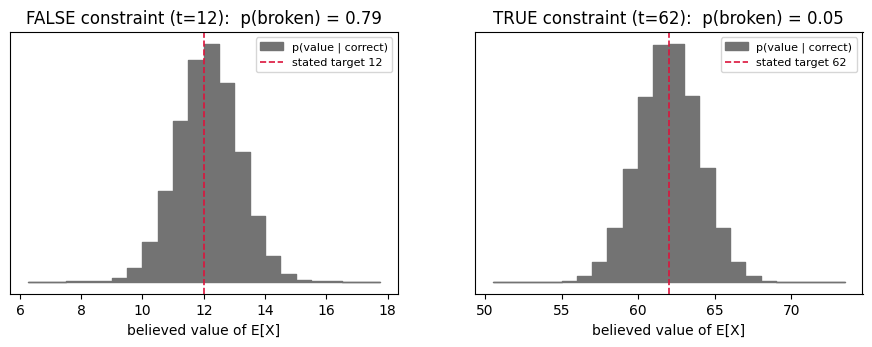

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for a, (v, pv, pb, t, lab) in zip(ax, [(vF, pvF, pbF, 12., "FALSE constraint (t=12)"),
                                       (vT, pvT, pbT, 62., "TRUE constraint (t=62)")]):
    a.fill_between(v, pv, step="mid", color="0.45", label="p(value | correct)")
    a.axvline(t, color="crimson", ls="--", lw=1.2, label=f"stated target {t:.0f}")
    a.set_title(f"{lab}:  p(broken) = {pb:.2f}")
    a.set_xlabel("believed value of E[X]"); a.set_yticks([]); a.legend(fontsize=8)
_FIG = fig

### 4. Takeaway

Same discrimination as the flagged spike-and-slab, but **nothing was tuned**: the
false constraint pushes its own posterior from 5% to ~80% broken and the fit fully
recovers, while the true constraint's posterior stays *at the prior* and its value
posterior sharpens around the truth. `enforce` is numerical stiffness (raise until
coupling residuals ~ 0), not a belief; the beliefs are `(target, value_sd,
p_broken)` — and trusted constraints are just the same statement with tiny
`p_broken` and small `sd`. The one structural requirement is the **broken bin**:
"asserts nothing" must be a state with *no coupling*, not a broad prior over
values — a slab both misprices doubt (its cost grows with bin count) and injects
phantom value-branches into the predictive.

## Appendix: posterior trust per constraint, method by method

The whole no-flag problem in one picture: for each of the four stated
constraints, how much does each method believe it after seeing the others?
Ideal is the dotted line (the `1 - p_broken = 0.95` prior) for the three true
constraints and ~0 for the false one (shaded). Spike-slab hedges everywhere,
belief separates but never convicts, on/off is the step function we wanted.

In [ ]:
labels = ["P(X>40)=0.85", "P(X>70)=0.35", "E[X]=62", "E[X]=12\n(false)"]

credA = []                                     # 2b spike-slab: credence window
for site, tgt, win in [(0, .85, .12), (1, .35, .12), (3, 62., 12.), (4, 12., 12.)]:
    pc = np.asarray(mA.joint_marginal(pA, site)); cc = mA.disc.bin_centers(site)
    credA.append(float(pc[np.abs(cc - tgt) < win].sum()))
credB = [1.0 - L.belief_readout(mB, pB, s)[0] for s in (0, 1, 3, 4)]   # 2c belief
credO = [float(np.asarray(mO.joint_marginal(pO, s))[1]) for s in (0, 1, 3, 4)]  # 2e

x = np.arange(4); wbar = 0.26
fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.axvspan(2.55, 3.55, color="crimson", alpha=0.07)
ax.bar(x - wbar, credA, wbar, color="darkorange", label="spike-slab (2b)")
ax.bar(x,        credB, wbar, color="purple",     label="belief (2c)")
ax.bar(x + wbar, credO, wbar, color="seagreen",   label="on/off (2e)")
ax.axhline(0.95, color="0.5", lw=1, ls=":")
ax.text(3.58, 0.955, "prior trust", fontsize=8, color="0.4", va="bottom", ha="right")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("posterior trust"); ax.set_ylim(0, 1.08)
ax.set_title("who do you believe? — trust in each constraint, per method")
ax.legend(fontsize=8, loc="center left")
_FIG2 = fig